# SoH vessel lifecycle — crude MEG panel

Rebuilds the hand-built vessel table from:
1. **Crossing history since 28 Feb 2026** (enter/exit clock — catches long-stayers)
2. **Kpler crude Trades** (port / grade / load date / destination / status)
3. **OFAC** flags (dark fleet as a **separate** panel)

**Questions**
- Which crude vessels are still inside MEG, and can they exit?
- Of indicated loadings in the next days, which nominated vessels still need to *enter* the strait?
- How is exit traffic behaving (is cargo still clearing)?

Universe for v1: **crude all sizes**. Dark fleet is reported in its own panel, not mixed into the main clean-fleet risk view.

**Kernel:** use the repo `.venv` (has `kpler.sdk`). Red Sea Saudi origins (Yanbu, Jeddah, …) are dropped after the Trades pull so Hormuz inbound logic stays Gulf-side.

## 1. Setup & config

In [13]:
from __future__ import annotations

from pathlib import Path
from datetime import date, timedelta
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 48)
pd.set_option("display.width", 160)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

BASE = Path(r"C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing")
CROSSING_PATH = BASE / "soh_crossing_hist.xlsx"
AFRA_PATH = BASE / "afra_scale_mapping.xlsx"
OFAC_IRAN_PATH = BASE / "ofac_iran_vessels_history.csv"
OFAC_SDN_PATH = BASE / "ofac_sdn_vessels_2026-07-13.csv"
ENV_PATH = BASE / ".env"

# Full crossing history used for "still inside" (fixes long-stayer bias)
HISTORY_START = date(2026, 2, 28)

# Focus window for exit-pulse / recent activity charts
FOCUS_START = date(2026, 6, 23)

# Forward look for scheduled / loading MEG crude
FORWARD_DAYS = 14

# Days inside without an exit before we flag "stuck risk"
STUCK_DAYS = 10

AS_OF = None  # None = max crossing date in file

MEG_ORIGIN_ZONES = [
    "Saudi Arabia",
    "Iraq",
    "United Arab Emirates",
    "Kuwait",
    "Qatar",
    "Iran",
]

# Saudi Arabia includes Red Sea terminals (Yanbu, Jeddah, …) that do NOT need SoH.
# Drop those after the Trades pull so inbound/Hormuz logic stays Gulf-side only.
RED_SEA_ORIGIN_KEYWORDS = (
    "yanbu",
    "jeddah",
    "rabigh",
    "muajjiz",
    "jizan",
    "jazan",
    "neom",
    "duba",
)

# Manual-name typos / aliases → crossing / Kpler names
NAME_ALIASES = {
    "DOMINCA PROSPERITY": "DOMINICA PROSPERITY",
    "MARA ANTILOPE": "MARAN ANTIOPE",
    "WEDIAN": "WEDYAN",
}

OUT_TABLE = BASE / "soh_crude_lifecycle.csv"
OUT_INSIDE = BASE / "likely_inside_v2.csv"
OUT_XLSX = BASE / "soh_crude_lifecycle.xlsx"

## 2. Helpers

In [14]:
def parse_env(path: Path) -> dict[str, str]:
    """Load KEY=value .env without printing secrets."""
    out: dict[str, str] = {}
    if not path.exists():
        return out
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        out[k.strip()] = v.strip()
    return out


def to_number(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )

def vessel_key(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.upper().replace(NAME_ALIASES)


def map_afra_class(dwt_kdwt: float, afra: pd.DataFrame) -> str | float:
    if pd.isna(dwt_kdwt):
        return np.nan
    for _, r in afra.iterrows():
        lo, hi = r["capacity_lower_bound"], r["capacity_upper_bound"]
        if lo <= dwt_kdwt < hi or (hi >= 550 and dwt_kdwt >= lo):
            return r["vessel_class"]
    if dwt_kdwt < afra["capacity_lower_bound"].min():
        return "Below GP"
    return "Above ULCC"


def is_crude_cargo(cargo_type) -> bool:
    if pd.isna(cargo_type):
        return False
    t = str(cargo_type).lower()
    return "crude" in t


def is_red_sea_origin(origin_name) -> bool:
    """True for Red Sea load ports that do not require a Hormuz transit."""
    if pd.isna(origin_name):
        return False
    o = str(origin_name).lower()
    return any(k in o for k in RED_SEA_ORIGIN_KEYWORDS)


def load_ofac_imos(iran_path: Path, sdn_path: Path) -> tuple[set[int], set[int]]:
    iran = pd.read_csv(iran_path)
    sdn = pd.read_csv(sdn_path)
    iran_imos = set(pd.to_numeric(iran["imo"], errors="coerce").dropna().astype(int))
    sdn_imos = set(pd.to_numeric(sdn["imo"], errors="coerce").dropna().astype(int))
    return iran_imos, sdn_imos

## 3. Load crossings + reference data

"Still inside" uses the **full file since `HISTORY_START`**, not only recent enters.

In [15]:
raw = pd.read_excel(CROSSING_PATH)
crossings = raw.copy()
crossings["Crossing Date"] = pd.to_datetime(
    crossings["Crossing Date"], dayfirst=True, errors="coerce"
)
crossings["IMO"] = pd.to_numeric(crossings["IMO"], errors="coerce").astype("Int64")
crossings["Quantity"] = to_number(crossings["Quantity"]).fillna(0.0)
crossings["Deadweight"] = to_number(crossings["Deadweight"])
crossings["dwt_kdwt"] = crossings["Deadweight"] / 1000.0
crossings["vessel_key"] = vessel_key(crossings["Vessel Name"])

afra = pd.read_excel(AFRA_PATH)
crossings["afra_class"] = crossings["dwt_kdwt"].map(lambda x: map_afra_class(x, afra))

iran_imos, sdn_imos = load_ofac_imos(OFAC_IRAN_PATH, OFAC_SDN_PATH)
crossings["sanctioned_iran"] = crossings["IMO"].isin(iran_imos)
crossings["sanctioned_sdn"] = crossings["IMO"].isin(sdn_imos)
crossings["is_dark_fleet"] = crossings["sanctioned_iran"] | crossings["sanctioned_sdn"]
crossings["fleet"] = np.where(crossings["is_dark_fleet"], "dark fleet", "clean fleet")

hist_start = pd.Timestamp(HISTORY_START)
hist = crossings[crossings["Crossing Date"] >= hist_start].copy()

data_max = hist["Crossing Date"].max().date()
data_min = hist["Crossing Date"].min().date()
as_of = AS_OF or data_max
as_of_ts = pd.Timestamp(as_of)

print(f"Crossing rows: {len(hist):,}  |  {data_min} → {data_max}")
print(f"Unique IMOs: {hist['IMO'].nunique():,}  |  as_of: {as_of}")
print(f"Dark-fleet IMOs in file: {hist.loc[hist['is_dark_fleet'], 'IMO'].nunique()}")

Crossing rows: 1,128  |  2026-02-28 → 2026-07-14
Unique IMOs: 599  |  as_of: 2026-07-14
Dark-fleet IMOs in file: 160


## 4. Vessel position from last crossing

For each IMO: last event in history ≤ `as_of`.
- last = **Entered MEG** → `in`
- last = **Exited MEG** → `out`

This is the fix vs the old `likely_inside` (which only saw vessels that *entered* inside a short window).

In [16]:
def build_lifecycle(df: pd.DataFrame, as_of_ts: pd.Timestamp) -> pd.DataFrame:
    """One row per IMO: last SoH event and derived in/out status."""
    use = df[df["Crossing Date"] <= as_of_ts].copy()
    use = use.sort_values(["IMO", "Crossing Date"])
    rows = []
    for imo, g in use.groupby("IMO", dropna=True):
        enters = g[g["Direction"] == "Entered MEG"]
        exits = g[g["Direction"] == "Exited MEG"]
        last = g.iloc[-1]
        status = (
            "in"
            if last["Direction"] == "Entered MEG"
            else "out"
            if last["Direction"] == "Exited MEG"
            else "unknown"
        )
        days_since_enter = (
            (as_of_ts - enters["Crossing Date"].max()).days if len(enters) else np.nan
        )
        days_since_exit = (
            (as_of_ts - exits["Crossing Date"].max()).days if len(exits) else np.nan
        )
        rows.append(
            {
                "imo": int(imo),
                "vessel_name": last["Vessel Name"],
                "vessel_key": last["vessel_key"],
                "flag": last["Flag Name"],
                "afra_class": last["afra_class"],
                "dwt": last["Deadweight"],
                "fleet": last["fleet"],
                "is_dark_fleet": bool(last["is_dark_fleet"]),
                "n_crossings": len(g),
                "n_enter": int((g["Direction"] == "Entered MEG").sum()),
                "n_exit": int((g["Direction"] == "Exited MEG").sum()),
                "first_enter": enters["Crossing Date"].min() if len(enters) else pd.NaT,
                "last_enter": enters["Crossing Date"].max() if len(enters) else pd.NaT,
                "last_exit": exits["Crossing Date"].max() if len(exits) else pd.NaT,
                "last_direction": last["Direction"],
                "last_crossing_date": last["Crossing Date"],
                "last_crossing_type": last["Crossing Type"],
                "last_loading_state_xing": last["Loading State"],
                "last_cargo_type_xing": last["Cargo Type"],
                "next_port_xing": last["Next Port"],
                "in_out": status,
                "days_since_enter": days_since_enter,
                "days_since_exit": days_since_exit,
            }
        )
    return pd.DataFrame(rows)


lifecycle = build_lifecycle(hist, as_of_ts)
inside = lifecycle[lifecycle["in_out"] == "in"].copy()

# Compare vs short-window method (FOCUS_START+) to quantify the long-stayer fix
short = build_lifecycle(hist[hist["Crossing Date"] >= pd.Timestamp(FOCUS_START)], as_of_ts)
short_in = set(short.loc[short["in_out"] == "in", "imo"])
full_in = set(inside["imo"])
long_stayers = full_in - short_in

print(f"Vessels with last event = Entered (full history since {HISTORY_START}): {len(inside)}")
print(f"Same method but only crossings since {FOCUS_START}: {len(short_in)}")
print(f"Long-stayers recovered by Feb-28 history: {len(long_stayers)}")
print()
print("Inside by fleet:")
print(inside["fleet"].value_counts().to_string())
print()
print("Inside by AFRA class:")
print(inside["afra_class"].value_counts().to_string())

inside.to_csv(OUT_INSIDE, index=False)
print(f"\nWrote {OUT_INSIDE.name}")

Vessels with last event = Entered (full history since 2026-02-28): 160
Same method but only crossings since 2026-06-23: 99
Long-stayers recovered by Feb-28 history: 61

Inside by fleet:
fleet
clean fleet    102
dark fleet      58

Inside by AFRA class:
afra_class
VLCC        60
LR1         44
Below GP    23
AFRA        10
GP           9
MR           7
LR2          5
ULCC         2

Wrote likely_inside_v2.csv


## 5. Kpler crude trades (MEG origins)

Pulls loadings / in-transit / scheduled crude from MEG countries.
Uses the project `.venv` + `vessel_crossing/.env` credentials.

In [17]:
cred = parse_env(ENV_PATH)
assert cred.get("KPLER_EMAIL") and cred.get("KPLER_PASSWORD"), (
    f"Missing KPLER_EMAIL / KPLER_PASSWORD in {ENV_PATH}"
)

from kpler.sdk import Platform, TradesStatus
from kpler.sdk.configuration import Configuration
from kpler.sdk.resources.trades import Trades

config = Configuration(Platform.Liquids, cred["KPLER_EMAIL"], cred["KPLER_PASSWORD"])
trades_client = Trades(config)

TRADE_COLS = [
    "vessel_name",
    "vessel_imo",
    "status",
    "closest_ancestor_product",
    "closest_ancestor_grade",
    "origin_location_name",
    "destination_location_name",
    "start",
    "end",
    "origin_start",
    "origin_end",
    "initial_seller_name",
    "charterer_name",
    "cargo_origin_barrels_split_by_product",
    "vessel_dwt_1",
]

# Back to HISTORY_START for completed MEG loads; forward for scheduled
trade_start = HISTORY_START
trade_end = as_of + timedelta(days=FORWARD_DAYS)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    trades = trades_client.get(
        products=["crude"],
        from_zones=MEG_ORIGIN_ZONES,
        start_date=trade_start,
        end_date=trade_end,
        with_forecast=True,
        with_intra_country=True,
        with_intra_region=True,
        trade_status=[
            TradesStatus.Scheduled,
            TradesStatus.Loading,
            TradesStatus.InTransit,
            TradesStatus.Delivered,
        ],
        columns=TRADE_COLS,
        size=5000,
    )

print(f"Kpler crude MEG-country trades (raw): {len(trades):,}  ({trade_start} → {trade_end})")
if len(trades) == 0:
    raise RuntimeError("No Kpler trades returned — check credentials / subscription / zone names.")

trades["start"] = pd.to_datetime(trades["start"], errors="coerce")
trades["origin_start"] = pd.to_datetime(trades.get("origin_start"), errors="coerce")
trades["vessel_imo"] = pd.to_numeric(trades["vessel_imo"], errors="coerce").astype("Int64")
trades["vessel_key"] = vessel_key(trades["vessel_name"])
# Prefer sailing / origin date for "loading_date"
trades["load_ts"] = trades["start"].fillna(trades["origin_start"])

# Keep Gulf-side origins only (Hormuz-relevant)
n_before = len(trades)
trades = trades[~trades["origin_location_name"].map(is_red_sea_origin)].copy()
print(f"Dropped Red Sea origins: {n_before - len(trades):,}  → Gulf-side trades: {len(trades):,}")
print(trades["status"].value_counts().to_string())
print("Top origins:")
print(trades["origin_location_name"].value_counts().head(12).to_string())

Kpler crude MEG-country trades (raw): 1,140  (2026-02-28 → 2026-07-28)
Dropped Red Sea origins: 464  → Gulf-side trades: 676
status
Delivered     408
In Transit    243
Scheduled      21
Loading         4
Top origins:
origin_location_name
ADCOP Fujairah       249
Kharg Island          88
Al Basrah             62
Zirku                 55
Juaymah               48
Das Island            35
Ras Tanura            30
Mina Al-Ahmadi        23
Umm Lulu              13
FOTT                  13
FPSO Soroosh          10
Jask Oil Terminal     10


## 6. Join: lifecycle × latest crude trade → vessel table

One row per vessel that either:
- has a MEG crude trade in the window, or
- is still inside and looks crude-related on the crossing (Crude/Co cargo or ballast VLCC/ULCC / LR2+ heading to a MEG load port).

Main panel = **clean fleet**. Dark fleet kept for the separate panel below.

In [18]:
def pick_trade_for_vessel(trades_df: pd.DataFrame, imo: int | None, vkey: str) -> pd.Series | None:
    """Prefer IMO match; else vessel name. Pick trade closest to as_of among active ones."""
    sub = pd.DataFrame()
    if imo is not None and not pd.isna(imo):
        sub = trades_df[trades_df["vessel_imo"] == int(imo)]
    if sub.empty and vkey:
        sub = trades_df[trades_df["vessel_key"] == vkey]
    if sub.empty:
        return None
    # Prefer scheduled/loading/in transit over delivered; then nearest load_ts to as_of
    status_rank = {"Loading": 0, "Scheduled": 1, "In Transit": 2, "Delivered": 3}
    sub = sub.copy()
    sub["_rank"] = sub["status"].map(status_rank).fillna(9)
    sub["_dd"] = (sub["load_ts"] - as_of_ts).abs()
    sub = sub.sort_values(["_rank", "_dd", "load_ts"])
    return sub.iloc[0]


# Latest trade snapshot keyed by IMO where possible
trade_by_imo = {}
for imo, g in trades.dropna(subset=["vessel_imo"]).groupby("vessel_imo"):
    trade_by_imo[int(imo)] = pick_trade_for_vessel(g, int(imo), g.iloc[0]["vessel_key"])

trade_by_key = {}
for vk, g in trades.groupby("vessel_key"):
    trade_by_key[vk] = pick_trade_for_vessel(g, None, vk)


def enrich_row(lc_row: pd.Series) -> dict:
    imo = lc_row["imo"]
    tr = trade_by_imo.get(int(imo)) if pd.notna(imo) else None
    if tr is None:
        tr = trade_by_key.get(lc_row["vessel_key"])

    has_crude_trade = tr is not None
    crude_on_xing = is_crude_cargo(lc_row["last_cargo_type_xing"])
    # Ballast large crude hulls still matter for Hormuz capacity / future loads
    large_crude_hull = lc_row["afra_class"] in {"VLCC", "ULCC", "LR2", "AFRA", "LR1"}

    out = lc_row.to_dict()
    out["has_crude_trade"] = has_crude_trade
    out["crude_relevant"] = bool(has_crude_trade or crude_on_xing or (lc_row["in_out"] == "in" and large_crude_hull))

    if has_crude_trade:
        out["loading_port"] = tr.get("origin_location_name")
        out["grade"] = tr.get("closest_ancestor_grade")
        out["loading_date"] = tr.get("load_ts")
        out["discharged"] = tr.get("destination_location_name")
        out["trade_status"] = tr.get("status")
        out["seller"] = tr.get("initial_seller_name")
        out["charterer"] = tr.get("charterer_name")
        out["volume_bbl"] = tr.get("cargo_origin_barrels_split_by_product")
        out["controller"] = tr.get("charterer_name") or tr.get("initial_seller_name")
    else:
        out["loading_port"] = np.nan
        out["grade"] = np.nan
        out["loading_date"] = pd.NaT
        out["discharged"] = lc_row["next_port_xing"]
        out["trade_status"] = np.nan
        out["seller"] = np.nan
        out["charterer"] = np.nan
        out["volume_bbl"] = np.nan
        out["controller"] = np.nan

    # Loading state: prefer trade activity, else crossing tag
    if has_crude_trade and str(out.get("trade_status")) in {"Scheduled", "Loading"}:
        out["last_loading_state"] = "ballast" if str(out["trade_status"]) == "Scheduled" else "loading"
    else:
        out["last_loading_state"] = (
            str(lc_row["last_loading_state_xing"]).lower()
            if pd.notna(lc_row["last_loading_state_xing"])
            else np.nan
        )

    # Stuck / exit candidate heuristics
    days_in = lc_row["days_since_enter"]
    out["stuck_risk"] = bool(
        lc_row["in_out"] == "in"
        and pd.notna(days_in)
        and days_in >= STUCK_DAYS
    )
    laden_like = str(out.get("last_loading_state", "")).lower() in {"laden", "loading"} or (
        has_crude_trade and str(out.get("trade_status")) == "In Transit" and lc_row["in_out"] == "in"
    )
    out["exit_candidate"] = bool(lc_row["in_out"] == "in" and laden_like)
    return out


enriched = pd.DataFrame([enrich_row(r) for _, r in lifecycle.iterrows()])
crude_universe = enriched[enriched["crude_relevant"]].copy()

# Also add scheduled/loading crude trades whose vessel has no crossing row yet
fwd_mask = trades["status"].isin(["Scheduled", "Loading"]) & (
    trades["load_ts"] >= as_of_ts - pd.Timedelta(days=2)
)
fwd = trades.loc[fwd_mask].copy()
known_imos = set(lifecycle["imo"].dropna().astype(int))
known_keys = set(lifecycle["vessel_key"])
orphan_rows = []
for _, tr in fwd.iterrows():
    imo = tr["vessel_imo"]
    vk = tr["vessel_key"]
    if (pd.notna(imo) and int(imo) in known_imos) or (vk in known_keys):
        continue
    orphan_rows.append(
        {
            "imo": int(imo) if pd.notna(imo) else pd.NA,
            "vessel_name": tr["vessel_name"],
            "vessel_key": vk,
            "flag": np.nan,
            "afra_class": np.nan,
            "dwt": tr.get("vessel_dwt_1"),
            "fleet": "dark fleet"
            if (pd.notna(imo) and int(imo) in (iran_imos | sdn_imos))
            else "clean fleet",
            "is_dark_fleet": bool(pd.notna(imo) and int(imo) in (iran_imos | sdn_imos)),
            "n_crossings": 0,
            "n_enter": 0,
            "n_exit": 0,
            "first_enter": pd.NaT,
            "last_enter": pd.NaT,
            "last_exit": pd.NaT,
            "last_direction": np.nan,
            "last_crossing_date": pd.NaT,
            "last_crossing_type": np.nan,
            "last_loading_state_xing": np.nan,
            "last_cargo_type_xing": np.nan,
            "next_port_xing": np.nan,
            "in_out": "outside_no_xing",  # needs inbound crossing to load
            "days_since_enter": np.nan,
            "days_since_exit": np.nan,
            "has_crude_trade": True,
            "crude_relevant": True,
            "loading_port": tr.get("origin_location_name"),
            "grade": tr.get("closest_ancestor_grade"),
            "loading_date": tr.get("load_ts"),
            "discharged": tr.get("destination_location_name"),
            "trade_status": tr.get("status"),
            "seller": tr.get("initial_seller_name"),
            "charterer": tr.get("charterer_name"),
            "volume_bbl": tr.get("cargo_origin_barrels_split_by_product"),
            "controller": tr.get("charterer_name") or tr.get("initial_seller_name"),
            "last_loading_state": "ballast",
            "stuck_risk": False,
            "exit_candidate": False,
        }
    )

if orphan_rows:
    crude_universe = pd.concat([crude_universe, pd.DataFrame(orphan_rows)], ignore_index=True)

crude_universe["loading_date"] = pd.to_datetime(crude_universe["loading_date"], errors="coerce")

clean = crude_universe[~crude_universe["is_dark_fleet"]].copy()
dark = crude_universe[crude_universe["is_dark_fleet"]].copy()

print(f"Crude-relevant vessels: {len(crude_universe)}  (clean={len(clean)}, dark={len(dark)})")
print("Clean in/out:")
print(clean["in_out"].value_counts(dropna=False).to_string())

display_cols = [
    "vessel_name",
    "imo",
    "fleet",
    "afra_class",
    "controller",
    "loading_port",
    "grade",
    "loading_date",
    "last_enter",
    "last_exit",
    "in_out",
    "days_since_enter",
    "last_loading_state",
    "trade_status",
    "discharged",
    "stuck_risk",
    "exit_candidate",
]
clean_in = clean[clean["in_out"] == "in"].sort_values(
    ["stuck_risk", "days_since_enter"], ascending=[False, False]
)
print(f"\nClean fleet currently inside (crude-relevant): {len(clean_in)}")
clean_in[display_cols].head(25)

Crude-relevant vessels: 327  (clean=213, dark=114)
Clean in/out:
in_out
out                130
in                  73
outside_no_xing     10

Clean fleet currently inside (crude-relevant): 73


,vessel_name,imo,fleet,afra_class,controller,loading_port,grade,loading_date,last_enter,last_exit,in_out,days_since_enter,last_loading_state,trade_status,discharged,stuck_risk,exit_candidate
104,ELKA APOLLON,9299111,clean fleet,AFRA,NaN,NaN,NaN,NaT,2026-02-28,NaT,in,136.0,ballast,NaN,Jebel Ali,True,False
171,STALLION,9399478,clean fleet,LR2,NaN,Das Island,Das,2026-04-27 09:19:00,2026-02-28,NaT,in,136.0,ballast,In Transit,Dubai Area,True,True
9,QUAR,9112117,clean fleet,LR1,NaN,NaN,NaN,NaT,2026-04-04,NaT,in,101.0,ballast,NaN,Mideast Gulf,True,False
162,NUSHEN,9387578,clean fleet,VLCC,NaN,NaN,NaN,NaT,2026-04-04,NaT,in,101.0,ballast,NaN,NaN,True,False
106,PEACE GULF,9304588,clean fleet,LR1,NaN,NaN,NaN,NaT,2026-05-11,2026-04-25,in,64.0,ballast,NaN,Hamriya,True,False
109,CELE,9306469,clean fleet,LR1,NaN,NaN,NaN,NaT,2026-05-12,NaT,in,63.0,laden,NaN,NaN,True,True
122,KAZIMAH III,9329693,clean fleet,VLCC,KPC,Mina Al-Ahmadi,Kuwait,2026-05-31 00:00:00,2026-05-25,NaT,in,50.0,ballast,In Transit,NaN,True,True
243,BUBYAN,9656034,clean fleet,LR1,NaN,NaN,NaN,NaT,2026-06-02,NaT,in,42.0,ballast,NaN,Al Zour,True,False
302,LORA,9917804,clean fleet,LR1,NaN,NaN,NaN,NaT,2026-06-08,2026-06-01,in,36.0,ballast,NaN,Jubail Industrial Port,True,False
213,AL RIQQA,9534808,clean fleet,VLCC,KPC,Mina Al-Ahmadi,Kuwait,2026-06-16 00:00:00,2026-06-10,2026-06-04,in,34.0,ballast,In Transit,NaN,True,True


## 7. Insights — clean fleet

Actionable reads for Hormuz: inventory inside, exit pulse, stuck risk, inbound needed for upcoming loads.

In [19]:
focus = hist[hist["Crossing Date"] >= pd.Timestamp(FOCUS_START)].copy()

# --- Headline numbers (clean / crude-relevant) ---
clean_inside = clean[clean["in_out"] == "in"]
clean_exit_cand = clean_inside[clean_inside["exit_candidate"]]
clean_stuck = clean_inside[clean_inside["stuck_risk"]]

# Upcoming loads: scheduled/loading with load date in [as_of-1, as_of+FORWARD]
upcoming = clean[
    clean["trade_status"].isin(["Scheduled", "Loading"])
    & clean["loading_date"].notna()
    & (clean["loading_date"] >= as_of_ts - pd.Timedelta(days=1))
    & (clean["loading_date"] <= as_of_ts + pd.Timedelta(days=FORWARD_DAYS))
].copy()

upcoming["needs_inbound"] = upcoming["in_out"].isin(["out", "outside_no_xing"])
upcoming["already_inside"] = upcoming["in_out"].eq("in")

print("=== CLEAN FLEET / CRUDE — HEADLINES ===")
print(f"As of {as_of}")
print(f"  Inside now:              {len(clean_inside):3d}")
print(f"  Exit candidates (laden): {len(clean_exit_cand):3d}")
print(f"  Stuck risk (≥{STUCK_DAYS}d inside): {len(clean_stuck):3d}")
print(f"  Upcoming loads ({FORWARD_DAYS}d):  {len(upcoming):3d}")
print(f"    · already inside:      {int(upcoming['already_inside'].sum()):3d}")
print(f"    · still need to enter: {int(upcoming['needs_inbound'].sum()):3d}")
print(f"  Long-stayers vs short window: {len(long_stayers)} IMOs recovered")

=== CLEAN FLEET / CRUDE — HEADLINES ===
As of 2026-07-14
  Inside now:               73
  Exit candidates (laden):  29
  Stuck risk (≥10d inside):  51
  Upcoming loads (14d):   23
    · already inside:       10
    · still need to enter:  13
  Long-stayers vs short window: 61 IMOs recovered


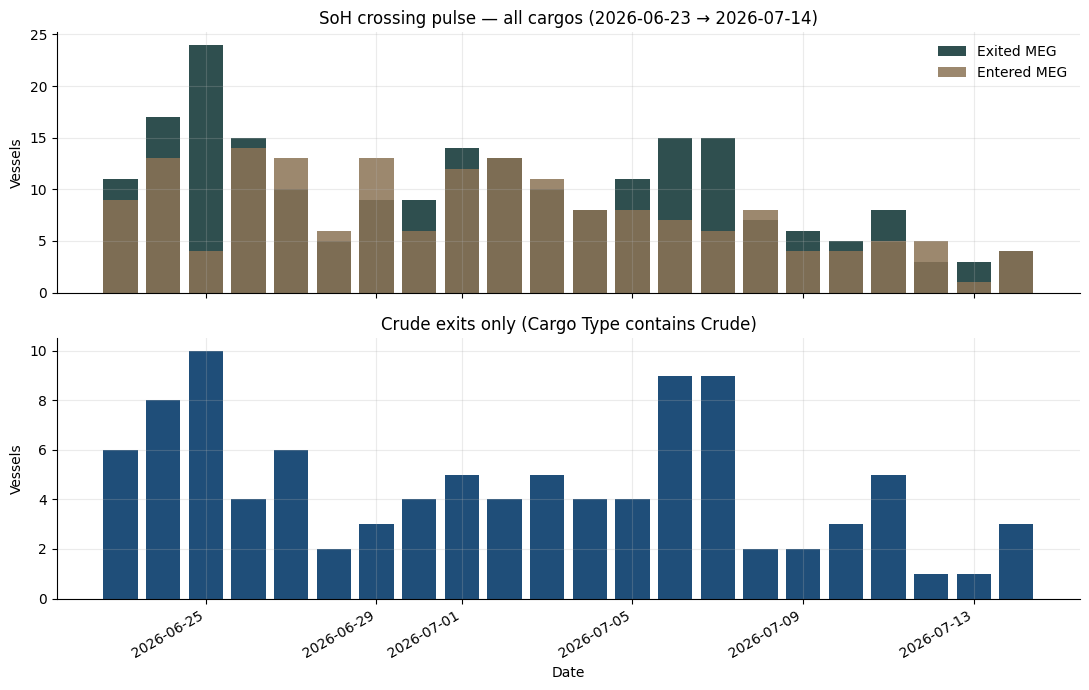

Focus window crude exits: 100  |  avg/day: 4.8


In [20]:
# Exit / enter pulse (all crossings in focus window; crude exits highlighted)
daily = (
    focus.assign(day=focus["Crossing Date"].dt.floor("D"))
    .groupby(["day", "Direction"])
    .size()
    .unstack(fill_value=0)
)
for col in ["Entered MEG", "Exited MEG"]:
    if col not in daily.columns:
        daily[col] = 0

crude_exits = focus[
    (focus["Direction"] == "Exited MEG") & focus["Cargo Type"].map(is_crude_cargo)
].assign(day=lambda d: d["Crossing Date"].dt.floor("D"))
crude_exit_daily = crude_exits.groupby("day").size()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].bar(daily.index, daily["Exited MEG"], width=0.8, color="#2f4f4f", label="Exited MEG")
axes[0].bar(daily.index, daily["Entered MEG"], width=0.8, color="#8b7355", alpha=0.85, label="Entered MEG")
axes[0].set_ylabel("Vessels")
axes[0].set_title(f"SoH crossing pulse — all cargos ({FOCUS_START} → {as_of})")
axes[0].legend(frameon=False)

axes[1].bar(crude_exit_daily.index, crude_exit_daily.values, width=0.8, color="#1f4e79")
axes[1].set_ylabel("Vessels")
axes[1].set_xlabel("Date")
axes[1].set_title("Crude exits only (Cargo Type contains Crude)")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(
    f"Focus window crude exits: {len(crude_exits)}  |  "
    f"avg/day: {len(crude_exits) / max((as_of - FOCUS_START).days, 1):.1f}"
)

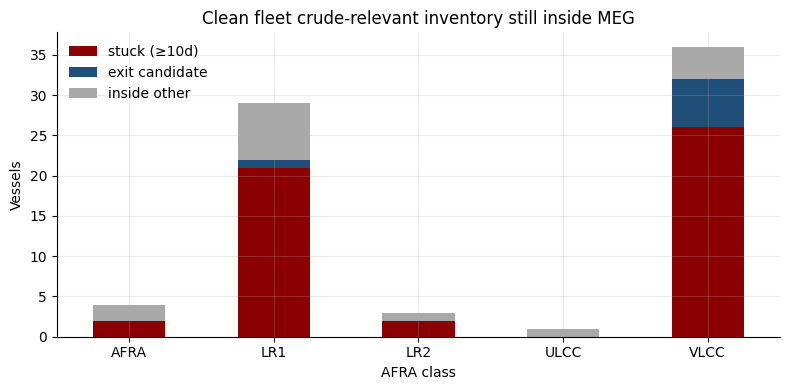

=== STUCK RISK (clean, ≥10d inside) ===


,vessel_name,imo,afra_class,days_since_enter,last_enter,loading_port,grade,loading_date,trade_status,last_loading_state,discharged
104,ELKA APOLLON,9299111,AFRA,136.0,2026-02-28,NaN,NaN,NaT,NaN,ballast,Jebel Ali
171,STALLION,9399478,LR2,136.0,2026-02-28,Das Island,Das,2026-04-27 09:19:00,In Transit,ballast,Dubai Area
9,QUAR,9112117,LR1,101.0,2026-04-04,NaN,NaN,NaT,NaN,ballast,Mideast Gulf
162,NUSHEN,9387578,VLCC,101.0,2026-04-04,NaN,NaN,NaT,NaN,ballast,NaN
106,PEACE GULF,9304588,LR1,64.0,2026-05-11,NaN,NaN,NaT,NaN,ballast,Hamriya
109,CELE,9306469,LR1,63.0,2026-05-12,NaN,NaN,NaT,NaN,laden,NaN
122,KAZIMAH III,9329693,VLCC,50.0,2026-05-25,Mina Al-Ahmadi,Kuwait,2026-05-31 00:00:00,In Transit,ballast,NaN
243,BUBYAN,9656034,LR1,42.0,2026-06-02,NaN,NaN,NaT,NaN,ballast,Al Zour
302,LORA,9917804,LR1,36.0,2026-06-08,NaN,NaN,NaT,NaN,ballast,Jubail Industrial Port
213,AL RIQQA,9534808,VLCC,34.0,2026-06-10,Mina Al-Ahmadi,Kuwait,2026-06-16 00:00:00,In Transit,ballast,NaN


In [21]:
# Inside inventory stack + stuck list
inv = clean_inside.copy()
inv["state"] = np.where(
    inv["stuck_risk"],
    "stuck (≥10d)",
    np.where(inv["exit_candidate"], "exit candidate", "inside other"),
)

fig, ax = plt.subplots(figsize=(8, 4))
by_class = (
    inv.groupby(["afra_class", "state"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["stuck (≥10d)", "exit candidate", "inside other"], fill_value=0)
)
by_class.plot(kind="bar", stacked=True, ax=ax, color=["#8b0000", "#1f4e79", "#a9a9a9"])
ax.set_title("Clean fleet crude-relevant inventory still inside MEG")
ax.set_xlabel("AFRA class")
ax.set_ylabel("Vessels")
ax.legend(frameon=False, title=None)
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

print("=== STUCK RISK (clean, ≥10d inside) ===")
stuck_cols = [
    "vessel_name",
    "imo",
    "afra_class",
    "days_since_enter",
    "last_enter",
    "loading_port",
    "grade",
    "loading_date",
    "trade_status",
    "last_loading_state",
    "discharged",
]
if len(clean_stuck):
    display(clean_stuck.sort_values("days_since_enter", ascending=False)[stuck_cols])
else:
    print("(none)")

=== UPCOMING MEG CRUDE LOADS — can nominated vessels enter? ===


,vessel_name,imo,loading_port,grade,loading_date,trade_status,in_out,last_enter,last_exit,needs_inbound,controller,discharged
326,Daryabandar 4,9794355,FPSO Soroosh,Soroosh,2026-07-15 21:31:00,Loading,outside_no_xing,NaT,NaT,True,NaN,NaN
325,New Honor,9799159,ADCOP Fujairah,Murban,2026-07-16 00:57:00,Loading,outside_no_xing,NaT,NaT,True,Sinopec,China
324,Front Nausta,9845714,ADCOP Fujairah,Murban,2026-07-16 11:39:00,Loading,outside_no_xing,NaT,NaT,True,Chevron,Americas
323,Seeb,9500716,Ras Tanura,Arab,2026-07-19 14:15:00,Scheduled,outside_no_xing,NaT,NaT,True,NATIONAL SHIPPING CO OF SAUDI ARABIA BAHRI,Eastern Asia
322,Al Samha,9380324,Ruwais,Murban,2026-07-20 08:57:00,Scheduled,outside_no_xing,NaT,NaT,True,ADNOC,NaN
321,Plata Singapore,9323936,Ras Tanura,Arab,2026-07-20 17:04:00,Scheduled,outside_no_xing,NaT,NaT,True,NaN,NaN
15,HELGA,9176993,Al Basrah,Basrah,2026-07-21 07:41:00,Scheduled,out,2026-06-02,2026-06-15,True,NaN,NaN
320,Lawhah,9783681,Ras Tanura,Arab,2026-07-22 08:03:00,Scheduled,outside_no_xing,NaT,NaT,True,Aramco,NaN
47,LUCIA A,9228655,Al Basrah,Basrah,2026-07-22 10:41:00,Scheduled,out,2026-06-15,2026-06-23,True,NaN,NaN
319,Jasmin Joy,9427471,Al Basrah,Basrah,2026-07-22 13:41:00,Scheduled,outside_no_xing,NaT,NaT,True,MRPL,Mangalore


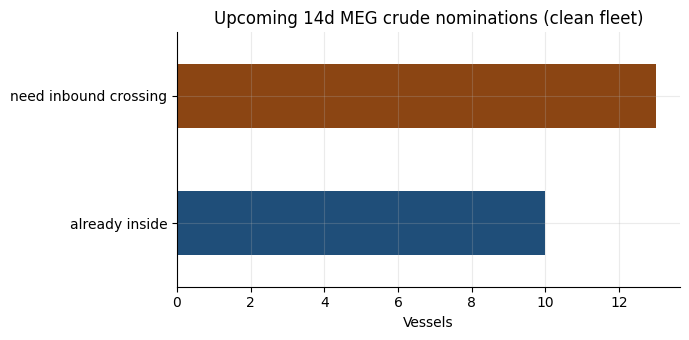

In [22]:
print("=== UPCOMING MEG CRUDE LOADS — can nominated vessels enter? ===")
up_cols = [
    "vessel_name",
    "imo",
    "loading_port",
    "grade",
    "loading_date",
    "trade_status",
    "in_out",
    "last_enter",
    "last_exit",
    "needs_inbound",
    "controller",
    "discharged",
]
if len(upcoming):
    display(
        upcoming.sort_values(["needs_inbound", "loading_date"], ascending=[False, True])[up_cols]
    )

    fig, ax = plt.subplots(figsize=(7, 3.5))
    counts = pd.Series(
        {
            "already inside": int(upcoming["already_inside"].sum()),
            "need inbound crossing": int(upcoming["needs_inbound"].sum()),
        }
    )
    counts.plot(kind="barh", ax=ax, color=["#1f4e79", "#8b4513"])
    ax.set_title(f"Upcoming {FORWARD_DAYS}d MEG crude nominations (clean fleet)")
    ax.set_xlabel("Vessels")
    fig.tight_layout()
    plt.show()
else:
    print("(no scheduled/loading clean-fleet crude trades in forward window)")

## 8. Dark fleet panel (separate)

Same lifecycle logic, reported apart so it does not distort the clean-fleet Hormuz clearance read.

=== DARK FLEET PANEL ===
Crude-relevant dark vessels in universe: 114
Currently inside: 48

Inside by AFRA / loading state:
last_loading_state  ballast  laden
afra_class                        
AFRA                      6      0
LR1                      12      3
LR2                       2      0
ULCC                      1      0
VLCC                     24      0


,vessel_name,imo,afra_class,days_since_enter,last_enter,loading_port,grade,trade_status,last_loading_state,next_port_xing,discharged
39,DOVER,9218466,VLCC,135.0,2026-03-01,FPSO Soroosh,Soroosh,In Transit,ballast,Soroosh,NaN
67,LOANNA,9251884,LR1,135.0,2026-03-01,NaN,NaN,NaN,ballast,NaN,NaN
69,FAROG,9252072,LR1,135.0,2026-03-01,NaN,NaN,NaN,ballast,NaN,NaN
16,DESTINY,9177155,VLCC,131.0,2026-03-05,NaN,NaN,NaN,ballast,South Pars,South Pars
95,WORLD COURAGE,9289740,LR1,123.0,2026-03-13,NaN,NaN,NaN,ballast,NaN,NaN
52,COBA,9235737,VLCC,107.0,2026-03-29,Kharg Island,Iran,In Transit,ballast,Kharg Island,NaN
89,KUSH,9282522,LR1,106.0,2026-03-30,NaN,NaN,NaN,ballast,NaN,NaN
22,ARGO I,9187667,AFRA,106.0,2026-03-30,NaN,NaN,NaN,ballast,Iran,Iran
74,UMA,9258870,AFRA,105.0,2026-03-31,FPSO Soroosh,Soroosh,In Transit,ballast,Soroosh,NaN
38,DEVON,9218454,VLCC,104.0,2026-04-01,NaN,NaN,NaN,ballast,NaN,NaN


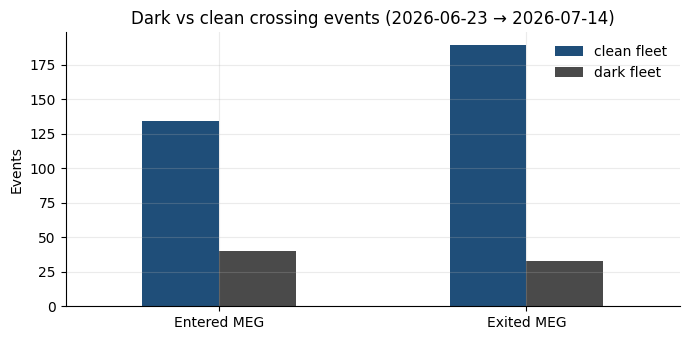

In [23]:
dark_inside = dark[dark["in_out"] == "in"]
print("=== DARK FLEET PANEL ===")
print(f"Crude-relevant dark vessels in universe: {len(dark)}")
print(f"Currently inside: {len(dark_inside)}")
print()
print("Inside by AFRA / loading state:")
if len(dark_inside):
    print(
        dark_inside.groupby(["afra_class", "last_loading_state"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .to_string()
    )
    display(
        dark_inside.sort_values("days_since_enter", ascending=False)[
            [
                "vessel_name",
                "imo",
                "afra_class",
                "days_since_enter",
                "last_enter",
                "loading_port",
                "grade",
                "trade_status",
                "last_loading_state",
                "next_port_xing",
                "discharged",
            ]
        ].head(40)
    )
else:
    print("(none inside)")

# Dark share of focus-window crossings
focus_dark = focus.copy()
fig, ax = plt.subplots(figsize=(7, 3.5))
share = (
    focus_dark.groupby(["Direction", "fleet"])
    .size()
    .unstack(fill_value=0)
)
share.plot(kind="bar", ax=ax, color=["#1f4e79", "#4a4a4a"])
ax.set_title(f"Dark vs clean crossing events ({FOCUS_START} → {as_of})")
ax.set_xlabel("")
ax.set_ylabel("Events")
ax.legend(frameon=False)
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

## 9. Export

CSV + Excel with sheets: `clean`, `dark`, `upcoming_loads`, `inside_all`.

In [24]:
export_cols = [
    c
    for c in [
        "vessel_name",
        "imo",
        "flag",
        "fleet",
        "afra_class",
        "dwt",
        "controller",
        "charterer",
        "seller",
        "loading_port",
        "grade",
        "loading_date",
        "volume_bbl",
        "last_enter",
        "last_exit",
        "in_out",
        "days_since_enter",
        "last_loading_state",
        "trade_status",
        "discharged",
        "stuck_risk",
        "exit_candidate",
        "last_crossing_type",
        "n_enter",
        "n_exit",
    ]
    if c in crude_universe.columns
]

crude_universe[export_cols].to_csv(OUT_TABLE, index=False)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as xlw:
    clean[export_cols].sort_values(["in_out", "loading_date"]).to_excel(
        xlw, sheet_name="clean", index=False
    )
    dark[export_cols].sort_values(["in_out", "days_since_enter"], ascending=[True, False]).to_excel(
        xlw, sheet_name="dark", index=False
    )
    if len(upcoming):
        upcoming[up_cols].to_excel(xlw, sheet_name="upcoming_loads", index=False)
    inside.to_excel(xlw, sheet_name="inside_all_cargos", index=False)

print(f"Wrote {OUT_TABLE.name}")
print(f"Wrote {OUT_XLSX.name}")
print("Done.")

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\luiscarlos.gaitan\\OneDrive - Jain Global\\Coding\\vessel_crossing\\soh_crude_lifecycle.xlsx'